# Выбор локации для скважины

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 10 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

## Загрузка и подготовка данных

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
df1 = pd.read_csv('/datasets/geo_data_0.csv')
df2 = pd.read_csv('/datasets/geo_data_1.csv')
df3 = pd.read_csv('/datasets/geo_data_2.csv')

(100000, 5)

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,f0,f1,f2,product
f0,1.000000,-0.440723,-0.003153,0.143536
f1,-0.440723,1.000000,0.001724,-0.192356
f2,-0.003153,0.001724,1.000000,0.483663
product,0.143536,-0.192356,0.483663,1.000000


0

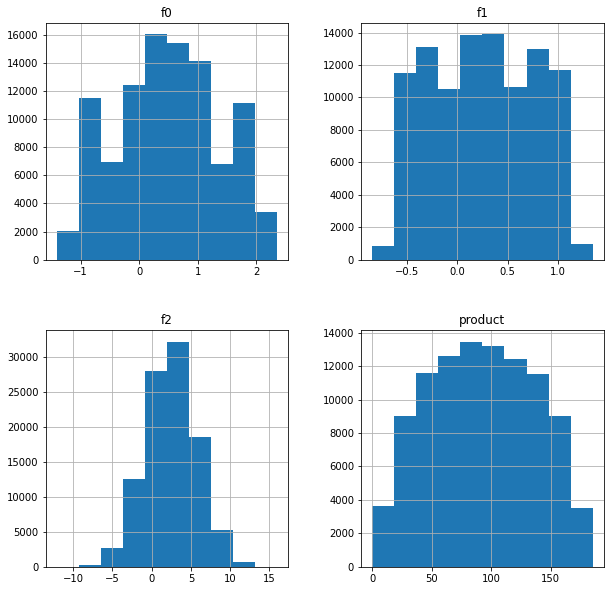

In [3]:
#df1
display(df1.shape)
display(df1.head())
display(df1.describe())
df1.info()
ax = df1.hist(figsize=(10, 10))
display(df1.corr())
df1.duplicated().sum()

(100000, 5)

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,f0,f1,f2,product
f0,1.000000,0.182287,-0.001777,-0.030491
f1,0.182287,1.000000,-0.002595,-0.010155
f2,-0.001777,-0.002595,1.000000,0.999397
product,-0.030491,-0.010155,0.999397,1.000000


0

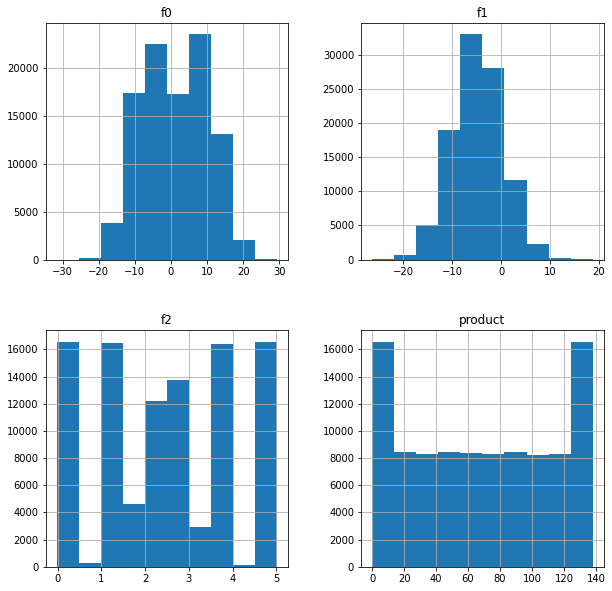

In [4]:
#df2
display(df2.shape)
display(df2.head())
display(df2.describe())
df2.info()
ax = df2.hist(figsize=(10, 10))
display(df2.corr())
df2.duplicated().sum()

(100000, 5)

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,f0,f1,f2,product
f0,1.000000,0.000528,-0.000448,-0.001987
f1,0.000528,1.000000,0.000779,-0.001012
f2,-0.000448,0.000779,1.000000,0.445871
product,-0.001987,-0.001012,0.445871,1.000000


0

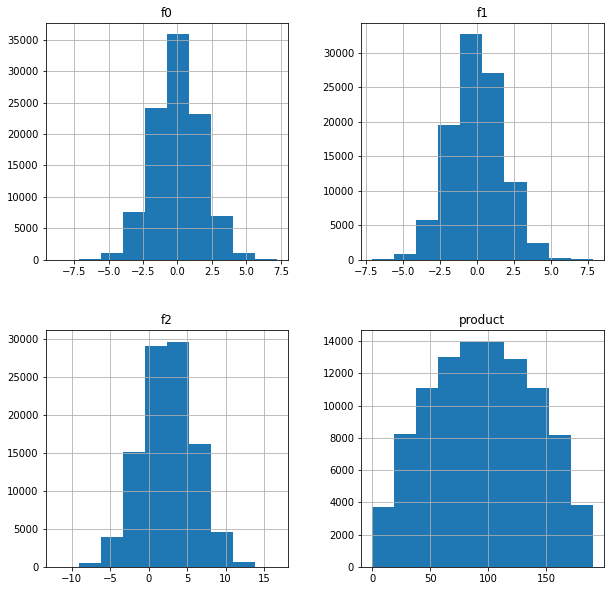

In [5]:
#df3
display(df3.shape)
display(df3.head())
display(df3.describe())
df3.info()
ax = df3.hist(figsize=(10, 10))
display(df3.corr())
df2.duplicated().sum()

После обзора данных можно сделать несколько выводов - в данных нет пропусков или явных дубликатов. Данные 3-его региона распределены относительно нормально. Данные второго региона f2 и product распределены не нормально. Данные из первого региона распределены относительно нормально. 

Корреляция между product и f2 для второго региона практически равна единице. Для третьего региона - 0.45, а для первого - 0.48. Так же в первом регионе присутсвует корреляция между f0 и f1 - 0.44.

## Обучение и проверка модели

In [6]:
#df1
features1 = df1[['f0', 'f1', 'f2']]
target1 = df1['product']

#Делим выборку
features_train1, features_valid1, target_train1, target_valid1 = train_test_split(
    features1, target1, test_size=0.25, random_state=12345)

#Линейная регрессия
model = LinearRegression()
model.fit(features_train1, target_train1) 
predictions_valid1 = model.predict(features_valid1) 
df1['predictions'] = model.predict(features1)
df_valid1 = df1.iloc[features_valid1.index, :]
print(predictions_valid1.mean())

mse = mean_squared_error(target_valid1, predictions_valid1)
rmse = mse ** 0.5
print("RMSE:", rmse)

92.59256778438035
RMSE: 37.5794217150813


In [7]:
#df2
features2 = df2[['f0', 'f1', 'f2']]
target2 = df2['product']

#Делим выборку
features_train2, features_valid2, target_train2, target_valid2 = train_test_split(
    features2, target2, test_size=0.25, random_state=12345)

#Линейная регрессия
model = LinearRegression()
model.fit(features_train2, target_train2) 
predictions_valid2 = model.predict(features_valid2) 
df2['predictions'] = model.predict(features2)
df_valid2 = df2.iloc[features_valid2.index, :]
print(predictions_valid2.mean())

mse = mean_squared_error(target_valid2, predictions_valid2)
rmse = mse ** 0.5
print("RMSE:", rmse)

68.728546895446
RMSE: 0.893099286775617


In [8]:
#df3
features3 = df3[['f0', 'f1', 'f2']]
target3 = df3['product']

#Делим выборку
features_train3, features_valid3, target_train3, target_valid3 = train_test_split(
    features3, target3, test_size=0.25, random_state=12345)

#Линейная регрессия
model = LinearRegression()
model.fit(features_train3, target_train3) 
predictions_valid3 = model.predict(features_valid3) 
df3['predictions'] = model.predict(features3)
df_valid3 = df3.iloc[features_valid3.index, :]
print(predictions_valid3.mean())

mse = mean_squared_error(target_valid3, predictions_valid3)
rmse = mse ** 0.5
print("RMSE:", rmse)

94.96504596800489
RMSE: 40.02970873393434


In [9]:
display (df_valid3.head())

,id,f0,f1,f2,product,predictions
71751,DMlgl,-1.444717,-3.861599,2.225805,61.212375,93.599633
80493,tbrRC,-1.418617,1.276544,-0.976433,41.850118,75.105159
2655,JRs1w,-4.587649,-0.413199,1.649268,57.776581,90.066809
53233,bidOx,1.871584,1.619101,4.273555,100.053761,105.162375
91141,AcBBB,-2.028785,4.128167,6.089547,109.897122,115.303310


Для первого региона среднее предсказание равно 93, rsme - 36; для второго среднее - 69, rsme - 0.89, для третьего - среднее - 95, rsme - 40.

## Подготовка к расчёту прибыли

In [10]:
drills = 200
price = 450
budget = 10000000
sample_size = 500
df1 = df1.sort_values(by = 'product', ascending=False)
df1 = df1.head(drills)
df1_mean = df1['product'].median()
print(df1_mean)

184.79867848528693


In [11]:
df2 = df2.sort_values(by = 'product', ascending=False)
df2 = df2.head(drills)
df2_mean = df2['product'].median()
print(df2_mean)

137.94540774090564


In [12]:
df3 = df3.sort_values(by = 'product', ascending=False)
df3 = df3.head(drills)
df3_mean = df3['product'].median()
print(df3_mean)

189.56032850625883


In [13]:
 #Достаточный объем product
break_even = budget/drills/price
print (break_even)

111.11111111111111


Таким образом, средние запасы из 200 самых богатых скажин в 1, 2 и 3 регионе равны 185, 138 и 190 соотсветсвенно. Во всех случаях значение больше минимального среднего для окупаемости проекта (111). 

In [14]:
state = np.random.RandomState(12345)
def profit(predictions):
    predictions = predictions.sample(sample_size, replace=True, random_state=state)
    predictions = predictions.sort_values(by='predictions')
    predictions = predictions['product'].tail(drills)
    return predictions.sum()*price - budget


In [29]:
# КОД РЕВЬЮЕРА
# предположим, у нас есть очень маленький датасет из 1 элемента целевой перемнной и соотв. 1 предсказания
target = pd.DataFrame({'target': [1]})
preds = pd.DataFrame({'pred': [1]})

display(target)
display(preds)

,target
0,1


,pred
0,1


In [30]:
# КОД РЕВЬЮЕРА
# сделаем бутстрапированную выборку предсказаний размера 2 и по индексам возьмём соотв. таргеты
preds_bs = preds.sample(n=2, replace=True)
target_bs = target.loc[preds_bs.index]

display(target_bs)
display(preds_bs)

,target
0,1
0,1


,pred
0,1
0,1


In [32]:
# КОД РЕВЬЮЕРА
# допустим, нам нужно взять 2 лучшие по предсказаниям точки и посчитать в них прибыль

preds_sorted = preds_bs.sort_values('pred', ascending=False)
target_selected = target_bs.loc[preds_sorted[:2].index]

display(preds_sorted)
display(target_selected)

,pred
0,1
0,1


,target
0,1
0,1
0,1
0,1


In [16]:
print (profit(df_valid1))
print (profit(df_valid2))
print (profit(df_valid3))

605464.0745689962
334315.67832436226
626175.5615691524


Исходя из предсказаний модели, прибыль для первого региона - 605 464 тыс.руб., для второго - 334 315 тыс.руб., для третьего - 626 175 тыс.руб.

## Расчёт прибыли и рисков 

In [17]:
# predictions_valid1 = pd.Series(predictions_valid1)
values = []
for i in range(1000):
    profit_subsample = profit(df_valid1)
    values.append(profit_subsample)

values = pd.Series(values)
count = 0
for j in values:
    if j < 0:
        count += 1
print("Риск:", count/len(values))
lower = values.quantile(0.025)
upper = values.quantile(0.975)
                
mean = values.mean()
print("Средняя выручка:", mean)
print(lower)
print(upper)

Риск: 0.07
Средняя выручка: 395259.1487435666
-111215.54589049603
909766.9415534238


In [18]:
# predictions_valid2 = pd.Series(predictions_valid2)
values = []
for i in range(1000):
    profit_subsample = profit(df_valid2)
    values.append(profit_subsample)

values = pd.Series(values)
count = 0
for j in values:
    if j < 0:
        count += 1
print("Риск:", count/len(values))        
lower = values.quantile(0.025)
upper = values.quantile(0.975)
                
mean = values.mean()
print("Средняя выручка:", mean)
print(lower)
print(upper)


Риск: 0.007
Средняя выручка: 462190.3249021853
78050.81075174287
862952.0602637231


In [19]:
# predictions_valid2 = pd.Series(predictions_valid2)
values = []
for i in range(1000):
    profit_subsample = profit(df_valid3)
    values.append(profit_subsample)

values = pd.Series(values)
count = 0
for j in values:
    if j < 0:
        count += 1
print("Риск:", count/len(values))
lower = values.quantile(0.025)
upper = values.quantile(0.975)
                
mean = values.mean()
print("Средняя выручка:", mean)
print(lower)
print(upper)

Риск: 0.065
Средняя выручка: 392446.3815803063
-112227.62537857569
934562.914551164


Проанализировав данные техникой bootstrap можно подвести итог - средние величины для 1, 2 и 3 регионов равны 395 259, 462 190 и 392 446 тыс руб соответсвенно. 95% довирительный интервал равен [909 766, -111 215], [862 952, 78 050] и [934 562, -112 227] соответсвенно. Риски убытков для регионов - 7%, 0.7%, 6.5%

В данном проекте были проанализированы данные, выявлены корреляции между признаками и наличие дубликатов. Были выявлены средние величины запасов как на предоставленных данных, так и на предсказаниях линейной регрессии. После это был проведен анализ техникой bootstrap, сделан анализ средней выручки, доверительного интервала 95% а также рассмотрен нижний квантиль 2.5% и риск убытка. По итогу можно сказать - самую большую среднюю прибыль предоставляет второй регион регион. Так же это единственный регион, где риск убытка меньше 2.5%. Из чего следует, что второй регион является единственным, удовлетворяющим условия для разведки